In [1]:
import os
import csv

root = "/Users/jocelynkavanagh/Documents/MUSI2526/Ballroom"

audio_root = os.path.join(root, "BallroomData")
beats_root = os.path.join(root, "BallroomAnnotations", "BallroomBeats")
tempo_root = os.path.join(root, "BallroomAnnotations", "ballroomTempo")

beat_out = os.path.join(root, "beat_csv")
tempo_out = os.path.join(root, "tempo_csv")

os.makedirs(beat_out, exist_ok=True)
os.makedirs(tempo_out, exist_ok=True)

for style in os.listdir(audio_root):

    style_path = os.path.join(audio_root, style)

    if not os.path.isdir(style_path):
        continue

    for file in os.listdir(style_path):

        if not file.endswith(".wav"):
            continue

        base = file.replace(".wav", "")

        bpm_path = os.path.join(tempo_root, base + ".bpm")
        beats_path = os.path.join(beats_root, base + ".beats")

        # -------------------------
        # TEMPO CSV
        # -------------------------

        if os.path.exists(bpm_path):

            with open(bpm_path) as f:
                bpm = float(f.read().strip())

            tempo_file = os.path.join(tempo_out, base + "_tempo.csv")

            with open(tempo_file, "w", newline="") as f:

                writer = csv.DictWriter(
                    f,
                    fieldnames=["file", "style", "tempo_bpm"]
                )

                writer.writeheader()
                writer.writerow({
                    "file": file,
                    "style": style,
                    "tempo_bpm": bpm
                })


        # -------------------------
        # BEAT CSV
        # -------------------------

        if os.path.exists(beats_path):

            beat_rows = []

            with open(beats_path) as f:

                for line in f:

                    parts = line.strip().split()

                    beat_time = float(parts[0])
                    beat_id = int(parts[1])

                    beat_rows.append({
                        "file": file,
                        "style": style,
                        "beat_time": beat_time,
                        "beat_id": beat_id
                    })

            beat_file = os.path.join(beat_out, base + "_beats.csv")

            with open(beat_file, "w", newline="") as f:

                writer = csv.DictWriter(
                    f,
                    fieldnames=["file", "style", "beat_time", "beat_id"]
                )

                writer.writeheader()
                writer.writerows(beat_rows)

print("Per-file beat and tempo CSVs created.")

PermissionError: [WinError 5] Access is denied: '/Users/jocelynkavanagh'

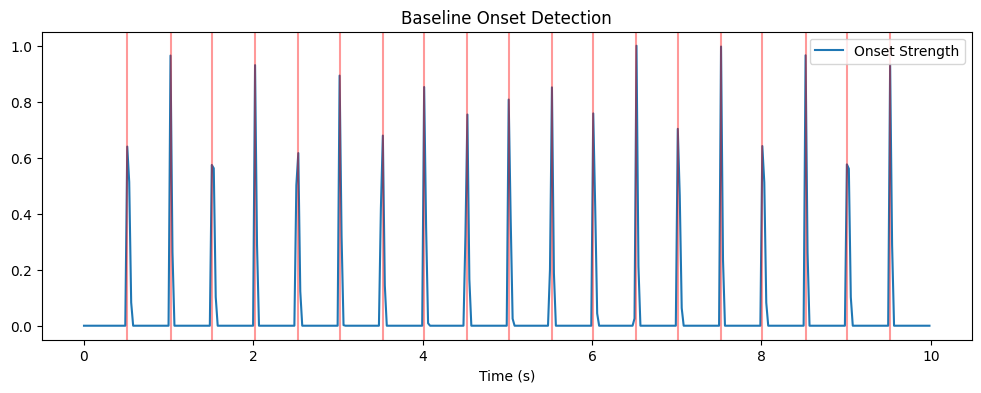

Expected number of clicks: 20
Detected onsets: 19
First few detected onset times: [0.510839   1.021678   1.50929705 2.02013605 2.53097506]


In [ ]:
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks



def baseline_onset_detector(x, sr, hop_length=512, peak_height=0.3):

    #Compute onset strength envelope
    onset_env = librosa.onset.onset_strength(y=x, sr=sr, hop_length=hop_length)
    
    # 2. Normalize
    onset_env = onset_env / np.max(onset_env)
    
    # 3. Peak picking
    peaks, _ = find_peaks(
        onset_env,
        height=peak_height,
        distance=2
    )
    
    # 4. Convert frames to time
    onset_times = librosa.frames_to_time(
        peaks,
        sr=sr,
        hop_length=hop_length
    )
    
    t = librosa.frames_to_time(np.arange(len(onset_env)), sr=sr, hop_length=512)

    plt.figure(figsize=(12, 4))
    plt.plot(t, onset_env, label="Onset Strength")

    for o in onset_times:
        plt.axvline(o, color='red', alpha=0.4)

    plt.xlabel("Time (s)")
    plt.title("Baseline Onset Detection")
    plt.legend()
    plt.show()
    return onset_times, onset_env



#test case. Having issues getting above audio to load into my computer
sr = 22050           # sampling rate
duration = 10.0      # seconds
bpm = 120            # tempo
click_freq = 1000    # Hz tone for clicks

t = np.linspace(0, duration, int(sr * duration), endpoint=False)

# Click times (seconds)
interval = 60 / bpm
click_times = np.arange(0, duration, interval)

# Create signal
x = np.zeros_like(t)

for ct in click_times:
    i = int(ct * sr)
    x[i:i + int(0.01 * sr)] += np.sin(
        2 * np.pi * click_freq * t[:int(0.01 * sr)]
    )

# Normalize
x = x / np.abs(x.max())

onset_times, onset_env = baseline_onset_detector(x, sr)

print("Expected number of clicks:", len(click_times))
print("Detected onsets:", len(onset_times))
print("First few detected onset times:", onset_times[:5])


